## 데이터분석 프로젝트 1

#### 메이저리그 야구 선수 시합 데이터 분석
(1) 구속이 빠른 10명과 느린 10명 비교  
(2) 투수의 구종 분석  
(3) 투수의 제구력 (스트라이크, 볼)  
(4) 투수의 구속 분석 (시즌별 / 회차별)

In [57]:
import pandas as pd
import seaborn as sns

df = pd.read_csv(r'C:\Users\sb730\Desktop\NVIDIA교육\실습 자료\mlb_data.csv')
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Columns: 119 entries, pitch_type to intercept_ball_minus_batter_pos_y_inches
dtypes: float64(68), int64(34), str(17)
memory usage: 25.0 MB
None
  pitch_type   game_date  release_speed  release_pos_x  release_pos_z  \
0         FF  2026-07-12           96.4          -1.07           5.74   
1         FF  2026-07-12           95.9          -1.15           5.69   
2         FS  2026-07-12           85.1          -2.62           5.50   
3         FF  2026-07-12           95.7          -2.33           5.62   
4         KC  2026-07-12           85.4          -1.05           5.81   

      player_name  batter  pitcher     events      description  ...  \
0      Baz, Shane  657041   669358     double    hit_into_play  ...   
1      Baz, Shane  657041   669358        NaN  swinging_strike  ...   
2  Gausman, Kevin  630105   592332  strikeout  swinging_strike  ...   
3  Gausman, Kevin  630105   592332        NaN    called_strike  ... 

### (1) 투수별 구속 비교

In [ ]:
# (1) 투수별 구속
speed_df = df[['game_date', 'release_speed', 'player_name', 'age_pit']]
speed_df

,game_date,release_speed,player_name,age_pit
0,2026-07-12,96.4,"Baz, Shane",27
1,2026-07-12,95.9,"Baz, Shane",27
2,2026-07-12,85.1,"Gausman, Kevin",35
3,2026-07-12,95.7,"Gausman, Kevin",35
4,2026-07-12,85.4,"Baz, Shane",27
...,...,...,...,...
24995,2026-07-07,95.1,"Dobbins, Hunter",27
24996,2026-07-07,96.8,"Cornelio, Riley",26
24997,2026-07-07,87.1,"Gallen, Zac",31
24998,2026-07-07,89.0,"Loáisiga, Jonathan",32


In [59]:
summary_df = speed_df.groupby(['player_name', 'age_pit'])['release_speed'].agg(
    최고구속='max',
    최저구속='min',
    평균구속='mean',
    구속편차='std'
).reset_index()

summary_df

,player_name,age_pit,최고구속,최저구속,평균구속,구속편차
0,"Abbott, Andrew",27,93.2,78.0,86.916168,4.903150
1,"Abner, Philip",24,92.0,82.1,88.250000,4.779435
2,"Abreu, Bryan",29,96.8,85.1,91.465217,4.754100
3,"Adams, Travis",26,95.9,85.5,89.343750,3.275022
4,"Agnos, Zach",26,95.1,81.9,90.352000,4.019444
...,...,...,...,...,...,...
414,"Young, Danny",32,95.4,81.7,88.331707,5.233853
415,"Zeferjahn, Ryan",28,98.6,79.9,90.655738,6.104357
416,"Zimmermann, Bruce",31,90.7,80.0,86.076923,3.389449
417,"Zuber, Tyler",31,96.5,82.7,90.170000,5.122981


In [60]:
sorted_df = summary_df.sort_values('평균구속', ascending = False)
sorted_df

,player_name,age_pit,최고구속,최저구속,평균구속,구속편차
135,"Guerrero, Tyron",35,102.2,96.5,99.668421,1.516772
244,"Misiorowski, Jacob",24,104.0,87.9,97.620833,5.594676
78,"Cruz, Steven",27,100.4,91.6,97.590909,2.578682
90,"Doval, Camilo",29,100.9,89.4,97.050000,4.011474
9,"Alvarado, Elvis",27,101.5,86.9,96.511111,5.050079
...,...,...,...,...,...,...
222,"Mateo, Jorge",31,77.6,43.1,64.584615,9.614126
400,"Williamson, Ben",26,51.1,48.0,49.080000,1.219426
150,"Higashioka, Kyle",36,65.9,39.1,45.987500,9.080373
358,"Stubbs, Garrett",33,46.4,42.7,44.125000,1.621471


In [61]:
top10_df = sorted_df[0:10]
top10_df

,player_name,age_pit,최고구속,최저구속,평균구속,구속편차
135,"Guerrero, Tyron",35,102.2,96.5,99.668421,1.516772
244,"Misiorowski, Jacob",24,104.0,87.9,97.620833,5.594676
78,"Cruz, Steven",27,100.4,91.6,97.590909,2.578682
90,"Doval, Camilo",29,100.9,89.4,97.050000,4.011474
9,"Alvarado, Elvis",27,101.5,86.9,96.511111,5.050079
374,"Uribe, Abner",26,101.8,86.6,96.197826,5.522419
64,"Chandler, Bubba",24,102.1,86.2,96.153608,3.800413
170,"Jones, Jared",25,100.6,88.0,96.036364,4.091130
323,"Schlittler, Cam",25,100.3,85.1,95.986869,3.625185
106,"Ferrer, José A.",26,101.0,86.6,95.910256,4.226408


In [62]:
bottom10_df = sorted_df[-10:]
bottom10_df

,player_name,age_pit,최고구속,최저구속,평균구속,구속편차
409,"Yarbrough, Ryan",35,88.2,70.9,82.304000,5.876115
307,"Rogers, Tyler",36,84.8,72.4,82.000000,4.089967
271,"Palmquist, Carson",26,92.5,72.5,81.961111,7.948072
75,"Cosgrove, Tom",30,87.8,68.1,74.130303,4.580085
74,"Cortes, Carlos",29,76.8,65.6,70.884211,3.890910
222,"Mateo, Jorge",31,77.6,43.1,64.584615,9.614126
400,"Williamson, Ben",26,51.1,48.0,49.080000,1.219426
150,"Higashioka, Kyle",36,65.9,39.1,45.987500,9.080373
358,"Stubbs, Garrett",33,46.4,42.7,44.125000,1.621471
372,"Torres, Bryan",29,52.6,32.2,42.227273,6.628588


In [63]:
import koreanize_matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

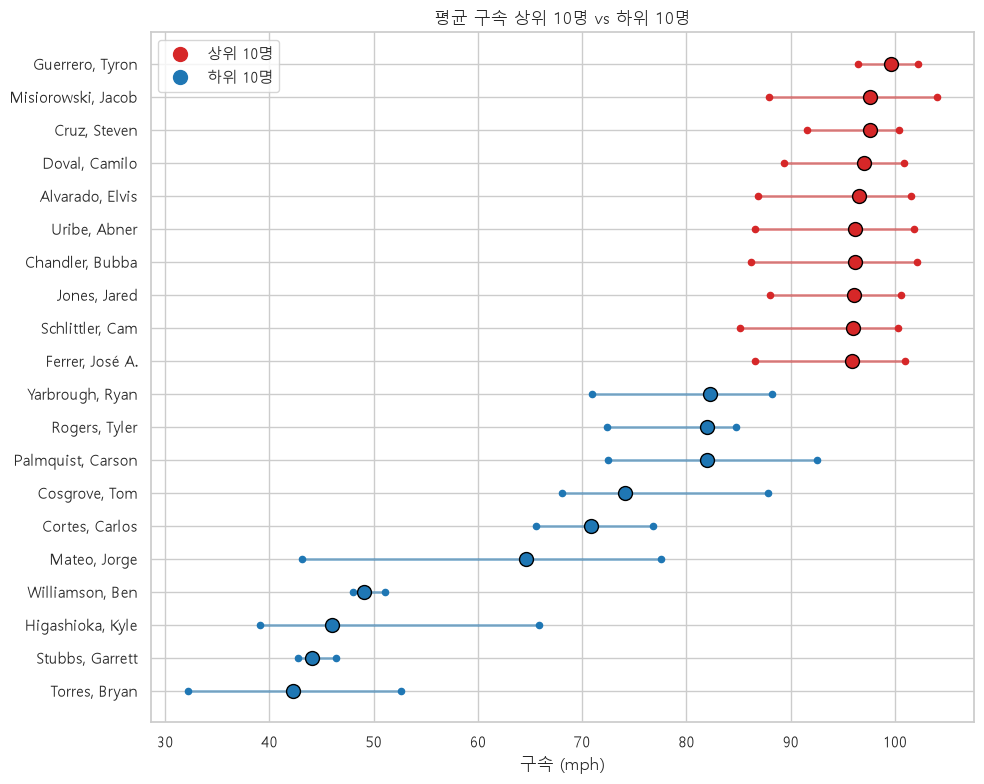

In [64]:
import matplotlib.pyplot as plt

# 그룹 라벨 추가 후 하나로 합치기
top10_df = top10_df.copy()
bottom10_df = bottom10_df.copy()
top10_df['그룹'] = '상위 10명'
bottom10_df['그룹'] = '하위 10명'

compare_df = pd.concat([top10_df, bottom10_df]).sort_values('평균구속', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'상위 10명': 'tab:red', '하위 10명': 'tab:blue'}

for i, row in enumerate(compare_df.itertuples()):
    color = colors[row.그룹]
    # 최저~최고 구속 범위 선
    ax.plot([row.최저구속, row.최고구속], [i, i], color=color, alpha=0.5, linewidth=2)
    # 최저/최고 점
    ax.scatter([row.최저구속, row.최고구속], [i, i], color=color, s=20)
    # 평균 구속 점 (더 크게, 진하게)
    ax.scatter(row.평균구속, i, color=color, s=100, edgecolor='black', zorder=3)

ax.set_yticks(range(len(compare_df)))
ax.set_yticklabels(compare_df['player_name'])
ax.set_xlabel('구속 (mph)')
ax.set_title('평균 구속 상위 10명 vs 하위 10명')

# 범례 수동 생성
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='tab:red', label='상위 10명', markersize=10, linestyle=''),
    Line2D([0], [0], marker='o', color='tab:blue', label='하위 10명', markersize=10, linestyle='')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

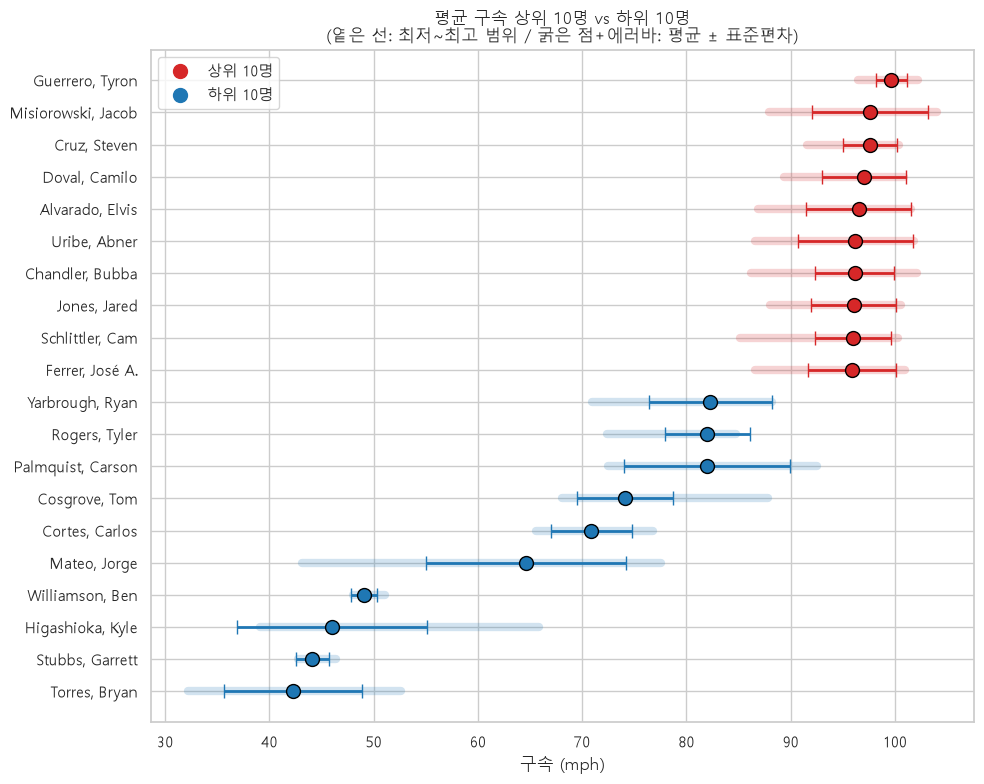

In [65]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 그룹 라벨 추가 후 하나로 합치기
top10_df = top10_df.copy()
bottom10_df = bottom10_df.copy()
top10_df['그룹'] = '상위 10명'
bottom10_df['그룹'] = '하위 10명'

compare_df = pd.concat([top10_df, bottom10_df]).sort_values('평균구속', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'상위 10명': 'tab:red', '하위 10명': 'tab:blue'}

for i, row in enumerate(compare_df.itertuples()):
    color = colors[row.그룹]
    
    # 1) 최저~최고 구속 범위 (옅은 배경 선)
    ax.plot([row.최저구속, row.최고구속], [i, i], color=color, alpha=0.2, linewidth=6)
    
    # 2) 평균 ± 표준편차 에러바 (진하게, 앞쪽에)
    ax.errorbar(
        row.평균구속, i,
        xerr=row.구속편차,
        fmt='o', color=color,
        markersize=10, markeredgecolor='black',
        capsize=5, elinewidth=2, zorder=3
    )

ax.set_yticks(range(len(compare_df)))
ax.set_yticklabels(compare_df['player_name'])
ax.set_xlabel('구속 (mph)')
ax.set_title('평균 구속 상위 10명 vs 하위 10명\n(옅은 선: 최저~최고 범위 / 굵은 점+에러바: 평균 ± 표준편차)')

legend_elements = [
    Line2D([0], [0], marker='o', color='tab:red', label='상위 10명', markersize=10, linestyle=''),
    Line2D([0], [0], marker='o', color='tab:blue', label='하위 10명', markersize=10, linestyle='')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### (2) 투수별 구종 분석

In [66]:
# (2) 투수별 구종
pitch_type_df = df[['pitch_type', 'player_name', 'type']]
pitch_type_df

,pitch_type,player_name,type
0,FF,"Baz, Shane",X
1,FF,"Baz, Shane",S
2,FS,"Gausman, Kevin",S
3,FF,"Gausman, Kevin",S
4,KC,"Baz, Shane",B
...,...,...,...
24995,FF,"Dobbins, Hunter",S
24996,FF,"Cornelio, Riley",S
24997,CH,"Gallen, Zac",S
24998,CU,"Loáisiga, Jonathan",B


In [67]:
pitch_type_pivot_df = pd.pivot_table(
    pitch_type_df,
    index=['player_name', 'pitch_type'],
    columns='type',
    aggfunc='size',
    fill_value=0
).reset_index()

pitch_type_pivot_df

type,player_name,pitch_type,B,S,X
0,"Abbott, Andrew",CH,7,15,9
1,"Abbott, Andrew",CU,10,8,2
2,"Abbott, Andrew",FC,3,6,0
3,"Abbott, Andrew",FF,27,35,8
4,"Abbott, Andrew",ST,8,20,9
...,...,...,...,...,...
1795,"deGrom, Jacob",CH,3,0,0
1796,"deGrom, Jacob",CU,4,6,0
1797,"deGrom, Jacob",FF,8,11,3
1798,"deGrom, Jacob",SI,1,2,3


In [68]:
skubal_df = pitch_type_pivot_df[pitch_type_pivot_df['player_name']=='Skubal, Tarik']
skubal_df

type,player_name,pitch_type,B,S,X
1482,"Skubal, Tarik",CH,12,21,7
1483,"Skubal, Tarik",CU,3,5,0
1484,"Skubal, Tarik",FF,27,45,7
1485,"Skubal, Tarik",SI,13,16,6
1486,"Skubal, Tarik",SL,7,8,5


In [69]:
skenes_df = pitch_type_pivot_df[pitch_type_pivot_df['player_name']=='Skenes, Paul']
skenes_df

type,player_name,pitch_type,B,S,X
1476,"Skenes, Paul",CH,7,1,5
1477,"Skenes, Paul",FF,26,50,15
1478,"Skenes, Paul",FS,6,11,6
1479,"Skenes, Paul",SI,2,2,2
1480,"Skenes, Paul",SL,5,10,3
1481,"Skenes, Paul",ST,7,12,0


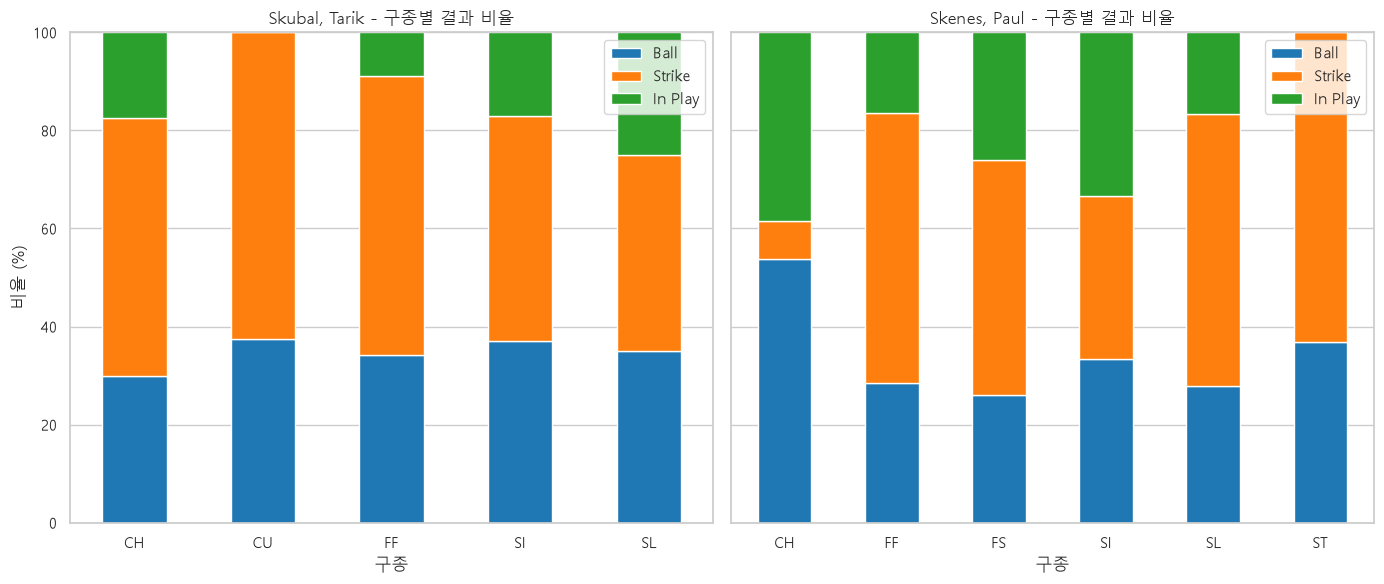

In [70]:
import matplotlib.pyplot as plt

def prepare_ratio(df):
    plot_df = df.set_index('pitch_type')[['B', 'S', 'X']]
    ratio_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100  # 행 기준 100% 정규화
    return ratio_df

skubal_ratio = prepare_ratio(skubal_df)
skenes_ratio = prepare_ratio(skenes_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

skubal_ratio.plot(kind='bar', stacked=True, ax=axes[0],
                   color=['tab:blue', 'tab:orange', 'tab:green'])
axes[0].set_title('Skubal, Tarik - 구종별 결과 비율')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xlabel('구종')
axes[0].legend(['Ball', 'Strike', 'In Play'])
axes[0].tick_params(axis='x', rotation=0)

skenes_ratio.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_title('Skenes, Paul - 구종별 결과 비율')
axes[1].set_xlabel('구종')
axes[1].legend(['Ball', 'Strike', 'In Play'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

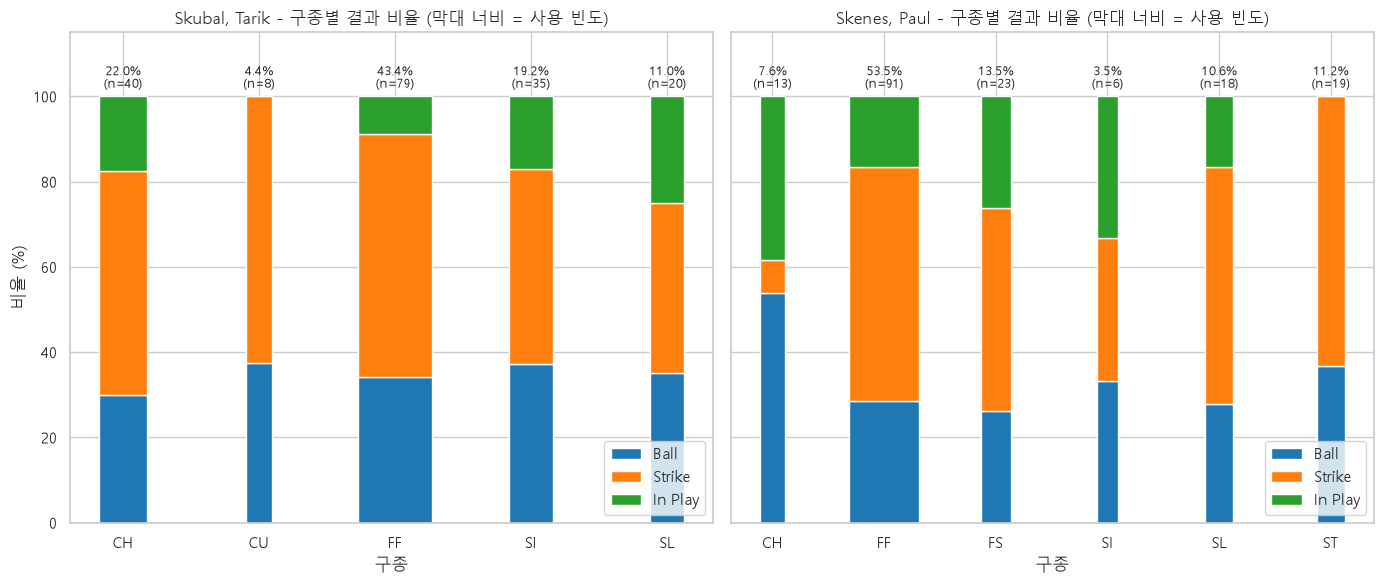

In [71]:
def prepare_data(df):
    plot_df = df.set_index('pitch_type')[['B', 'S', 'X']]
    total = plot_df.sum(axis=1)
    ratio_df = plot_df.div(total, axis=0) * 100  # 결과 비율(%)
    usage_pct = (total / total.sum() * 100).round(1)  # 구종 사용 비율(%)
    return ratio_df, usage_pct, total

skubal_ratio, skubal_usage, skubal_total = prepare_data(skubal_df)
skenes_ratio, skenes_usage, skenes_total = prepare_data(skenes_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

def plot_with_usage(ax, ratio_df, usage_pct, total, title):
    # 막대 너비를 usage%에 비례하게 설정 (최소 너비 보장)
    widths = (usage_pct / 100 * 0.9 + 0.15).values
    x = np.arange(len(ratio_df))
    
    bottom = np.zeros(len(ratio_df))
    colors = {'B': 'tab:blue', 'S': 'tab:orange', 'X': 'tab:green'}
    for col in ['B', 'S', 'X']:
        ax.bar(x, ratio_df[col], width=widths, bottom=bottom, color=colors[col], label=col)
        bottom += ratio_df[col].values
    
    # 막대 위에 usage% 표시
    for i, (u, t) in enumerate(zip(usage_pct, total)):
        ax.text(x[i], 102, f'{u}%\n(n={int(t)})', ha='center', fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(ratio_df.index)
    ax.set_title(title)
    ax.set_xlabel('구종')
    ax.set_ylim(0, 115)

plot_with_usage(axes[0], skubal_ratio, skubal_usage, skubal_total, 'Skubal, Tarik - 구종별 결과 비율 (막대 너비 = 사용 빈도)')
axes[0].set_ylabel('비율 (%)')
axes[0].legend(['Ball', 'Strike', 'In Play'], loc='lower right')

plot_with_usage(axes[1], skenes_ratio, skenes_usage, skenes_total, 'Skenes, Paul - 구종별 결과 비율 (막대 너비 = 사용 빈도)')
axes[1].legend(['Ball', 'Strike', 'In Play'], loc='lower right')

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 예시
plt.tight_layout()
plt.show()

### (3) 제구력 비교

In [ ]:
control_df = df[['release_speed', 'player_name', 'zone', 'type']]
control_df

,release_speed,player_name,zone,type
0,96.4,"Baz, Shane",1.0,X
1,95.9,"Baz, Shane",4.0,S
2,85.1,"Gausman, Kevin",13.0,S
3,95.7,"Gausman, Kevin",9.0,S
4,85.4,"Baz, Shane",14.0,B
...,...,...,...,...
24995,95.1,"Dobbins, Hunter",5.0,S
24996,96.8,"Cornelio, Riley",8.0,S
24997,87.1,"Gallen, Zac",4.0,S
24998,89.0,"Loáisiga, Jonathan",14.0,B


In [74]:
skubal_control_df = control_df[control_df['player_name']=='Skubal, Tarik']
skubal_control_df

,release_speed,player_name,zone,type
41,98.3,"Skubal, Tarik",3.0,X
49,98.8,"Skubal, Tarik",3.0,S
56,81.3,"Skubal, Tarik",3.0,S
61,89.1,"Skubal, Tarik",9.0,S
69,88.0,"Skubal, Tarik",14.0,B
...,...,...,...,...
24427,95.2,"Skubal, Tarik",12.0,B
24554,96.8,"Skubal, Tarik",12.0,B
24630,87.6,"Skubal, Tarik",13.0,S
24762,83.0,"Skubal, Tarik",13.0,S


최저 구속: 79.4, 최고 구속: 99.5


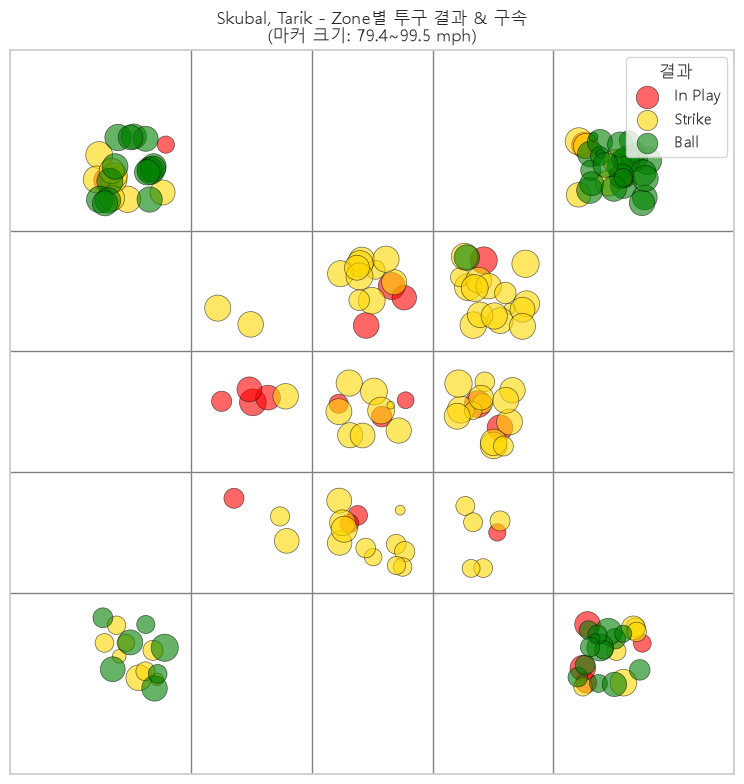

In [79]:
import numpy as np

# zone 번호 -> (x, y) 중심 좌표 매핑
zone_coords = {
    1: (1, 3), 2: (2, 3), 3: (3, 3),
    4: (1, 2), 5: (2, 2), 6: (3, 2),
    7: (1, 1), 8: (2, 1), 9: (3, 1),
    11: (0, 4), 12: (4, 4),
    13: (0, 0), 14: (4, 0),
}

color_map = {'X': 'red', 'S': 'gold', 'B': 'green'}

skubal_zone_df = skubal_control_df.copy()

# --- 구속 최저/최고값 확인 ---
speed_min = skubal_zone_df['release_speed'].min()
speed_max = skubal_zone_df['release_speed'].max()
print(f'최저 구속: {speed_min}, 최고 구속: {speed_max}')

# --- 마커 크기 정규화 (원하는 최소/최대 마커 크기로 스케일링) ---
MIN_MARKER_SIZE = 30    # 가장 느린 공의 마커 크기
MAX_MARKER_SIZE = 400   # 가장 빠른 공의 마커 크기

def scale_marker_size(speed, speed_min, speed_max, min_size, max_size):
    # 0~1 사이로 정규화 후, min_size~max_size 범위로 변환
    normalized = (speed - speed_min) / (speed_max - speed_min)
    return normalized * (max_size - min_size) + min_size

skubal_zone_df['marker_size'] = scale_marker_size(
    skubal_zone_df['release_speed'], speed_min, speed_max,
    MIN_MARKER_SIZE, MAX_MARKER_SIZE
)

# 좌표 매핑 + jitter 추가
np.random.seed(42)
skubal_zone_df['x'] = skubal_zone_df['zone'].map(lambda z: zone_coords[z][0]) + np.random.uniform(-0.3, 0.3, len(skubal_zone_df))
skubal_zone_df['y'] = skubal_zone_df['zone'].map(lambda z: zone_coords[z][1]) + np.random.uniform(-0.3, 0.3, len(skubal_zone_df))

fig, ax = plt.subplots(figsize=(8, 8))

for t, c in color_map.items():
    sub = skubal_zone_df[skubal_zone_df['type'] == t]
    ax.scatter(
        sub['x'], sub['y'],
        s=sub['marker_size'],
        c=c, alpha=0.6, edgecolor='black', linewidth=0.5,
        label={'X': 'In Play', 'S': 'Strike', 'B': 'Ball'}[t]
    )

for i in [0.5, 1.5, 2.5, 3.5]:
    ax.axvline(i, color='gray', linewidth=1)
    ax.axhline(i, color='gray', linewidth=1)

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'Skubal, Tarik - Zone별 투구 결과 & 구속\n(마커 크기: {speed_min}~{speed_max} mph)')
ax.legend(loc='upper right', title='결과')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### (4) 투수별 구속 분석 (시즌별, 회차별)

In [84]:
dte_df = pd.read_csv(r'C:\Users\sb730\Desktop\NVIDIA교육\실습 자료\skubal_data.csv')
dte_df = dte_df[['pitch_type', 'player_name','game_date', 'release_speed', 'game_year']]
raw_skubal_df = dte_df[dte_df['player_name']=='Skubal, Tarik']
raw_skubal_df

,pitch_type,player_name,game_date,release_speed,game_year
0,SI,"Skubal, Tarik",2026-07-12,98.3,2026
1,FF,"Skubal, Tarik",2026-07-12,98.8,2026
2,CU,"Skubal, Tarik",2026-07-12,81.3,2026
3,CH,"Skubal, Tarik",2026-07-12,89.1,2026
4,CH,"Skubal, Tarik",2026-07-12,88.0,2026
...,...,...,...,...,...
24979,CH,"Skubal, Tarik",2025-06-29,89.4,2025
24981,FF,"Skubal, Tarik",2025-06-29,97.6,2025
24983,FF,"Skubal, Tarik",2025-06-29,97.3,2025
24987,CH,"Skubal, Tarik",2025-06-29,87.1,2025


In [87]:
skubal_summary_df = raw_skubal_df.groupby(['pitch_type','player_name', 'game_year'])['release_speed'].agg(
    최고구속='max',
    최저구속='min',
    평균구속='mean',
    구속편차='std'
).reset_index()

skubal_summary_df

,pitch_type,player_name,game_year,최고구속,최저구속,평균구속,구속편차
0,CH,"Skubal, Tarik",2025,92.8,83.5,87.709735,1.461735
1,CH,"Skubal, Tarik",2026,92.0,83.6,87.351903,1.556217
2,CU,"Skubal, Tarik",2025,84.7,78.8,81.219565,1.460992
3,CU,"Skubal, Tarik",2026,83.0,77.9,80.426087,1.236561
4,FF,"Skubal, Tarik",2025,101.5,94.0,97.508824,1.244212
5,FF,"Skubal, Tarik",2026,99.6,92.5,96.744064,1.138126
6,SI,"Skubal, Tarik",2025,100.6,94.2,97.279505,1.259659
7,SI,"Skubal, Tarik",2026,100.4,93.6,96.740271,1.165550
8,SL,"Skubal, Tarik",2025,94.2,87.2,90.450943,1.478918
9,SL,"Skubal, Tarik",2026,92.6,86.1,89.362874,1.282199


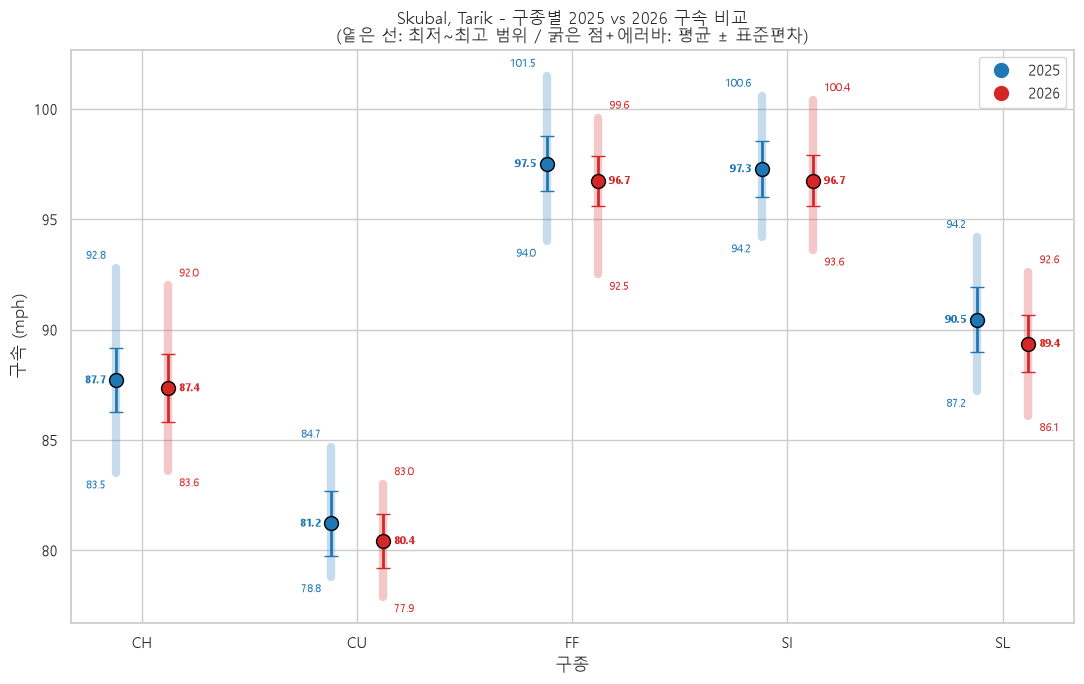

In [92]:
df = skubal_summary_df.copy()  # 첨부하신 데이터프레임

pitch_types = sorted(df['pitch_type'].unique())
years = [2025, 2026]
year_colors = {2025: 'tab:blue', 2026: 'tab:red'}
offset = {2025: -0.12, 2026: 0.12}
text_ha = {2025: 'right', 2026: 'left'}  # 값 텍스트를 마커 기준 좌/우로 배치해 겹침 방지
text_dx = {2025: -0.05, 2026: 0.05}

fig, ax = plt.subplots(figsize=(11, 7))

x_base = np.arange(len(pitch_types))

for year in years:
    color = year_colors[year]
    for i, pt in enumerate(pitch_types):
        row = df[(df['pitch_type'] == pt) & (df['game_year'] == year)]
        if row.empty:
            continue
        row = row.iloc[0]
        x = x_base[i] + offset[year]

        # 1) 최저~최고 범위 (옅은 선)
        ax.plot([x, x], [row['최저구속'], row['최고구속']], color=color, alpha=0.25, linewidth=6)

        # 2) 평균 ± 표준편차 (진한 에러바)
        ax.errorbar(
            x, row['평균구속'],
            yerr=row['구속편차'],
            fmt='o', color=color,
            markersize=10, markeredgecolor='black',
            capsize=5, elinewidth=2, zorder=3
        )

        # 3) 최고구속 값 텍스트
        ax.text(x + text_dx[year], row['최고구속'] + 0.3, f"{row['최고구속']:.1f}",
                 ha=text_ha[year], va='bottom', fontsize=8, color=color)

        # 4) 최저구속 값 텍스트
        ax.text(x + text_dx[year], row['최저구속'] - 0.3, f"{row['최저구속']:.1f}",
                 ha=text_ha[year], va='top', fontsize=8, color=color)

        # 5) 평균구속 값 텍스트
        ax.text(x + text_dx[year], row['평균구속'], f"{row['평균구속']:.1f}",
                 ha=text_ha[year], va='center', fontsize=8, fontweight='bold', color=color)

ax.set_xticks(x_base)
ax.set_xticklabels(pitch_types)
ax.set_xlabel('구종')
ax.set_ylabel('구속 (mph)')
ax.set_title('Skubal, Tarik - 구종별 2025 vs 2026 구속 비교\n(옅은 선: 최저~최고 범위 / 굵은 점+에러바: 평균 ± 표준편차)')

legend_elements = [
    Line2D([0], [0], marker='o', color=year_colors[2025], label='2025', markersize=10, linestyle=''),
    Line2D([0], [0], marker='o', color=year_colors[2026], label='2026', markersize=10, linestyle='')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()